<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/California_Housing_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Oscar Mercado


# California Housing con PyTorch


In [ ]:
V = '\033[92m'  # Verde
R = '\033[91m'  # Rojo
A = '\033[94m'  # Azul
E = '\033[0m'   # Reset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

**Cargar dataset**

In [ ]:
print(f"{A}Cargando dataset...{E}")

data = fetch_california_housing(as_frame=True)
df = data.frame #⚠️

print(f"{V}✔ Dataset cargado correctamente{E}")
df.head()

Cargando dataset...
✔ Dataset cargado correctamente


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Split 80/10/10**

In [ ]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_temp, y_train, y_temp = train_test_split( #⚠️
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(  #⚠️
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"{A}División de datos{E}")
print(f"{V}Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}{E}")

División de datos
Train: 16512 | Val: 2064 | Test: 2064


**Eliminar outliers (solo TRAIN)**

In [ ]:
cols = [c for c in X_train.columns if c not in ["Latitude", "Longitude"]]

Q1 = X_train[cols].quantile(0.25)
Q3 = X_train[cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((X_train[cols] < (Q1 - 1.5 * IQR)) |
         (X_train[cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print(f"{A}Eliminando outliers...{E}")
print(f"{V}Antes: {len(X_train)}{E}")

X_train = X_train[mask]
y_train = y_train[mask] #⚠️

print(f"{V}Después: {len(X_train)}{E}")

Eliminando outliers...
Antes: 16512
Después: 13460


**SCALING (dim=0)**

In [ ]:
scaled_cols = [c for c in X_train.columns if c not in ["Latitude", "Longitude"]]

train_tensor = torch.tensor(
    X_train[scaled_cols].values,  #⚠️
    dtype=torch.float32
)

mean = train_tensor.mean(dim=0)
std = train_tensor.std(dim=0)

print(f"{A}Calculando scaling (dim=0 por feature){E}")
print(f"{V}Mean shape: {mean.shape}{E}")
print(f"{V}Std shape: {std.shape}{E}")

Calculando scaling (dim=0 por feature)
Mean shape: torch.Size([6])
Std shape: torch.Size([6])


**TENSORES**

In [ ]:
def to_tensors(X, y):
    X_scaled = torch.tensor(X[scaled_cols].values, dtype=torch.float32)
    X_geo = torch.tensor(X[["Latitude", "Longitude"]].values, dtype=torch.float32)
    y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
    return X_scaled, X_geo, y

X_train_s, X_train_g, y_train_t = to_tensors(X_train, y_train)  #⚠️
X_val_s, X_val_g, y_val_t = to_tensors(X_val, y_val)
X_test_s, X_test_g, y_test_t = to_tensors(X_test, y_test)

print(f"{V}✔ Tensores listos{E}")

✔ Tensores listos


**PREPROCESAMIENTO (PYTORCH)**

In [ ]:
class ScalingLayer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / (self.std + 1e-8)


class PreprocessingLayer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.scaler = ScalingLayer(mean, std)

    def forward(self, x_scaled, x_geo):       #⚠️
        x_scaled = self.scaler(x_scaled)
        return torch.cat([x_scaled, x_geo], dim=1)

**MODELO**

In [ ]:
def train_model(model, optimizer, epochs=50):
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        preds = model(X_train_s, X_train_g)
        loss = loss_fn(preds, y_train_t)

        loss.backward()
        optimizer.step()

        # evaluación en validation
        val_loss = evaluate(model, X_val_s, X_val_g, y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss) #⚠️

        if epoch % 10 == 0:
            print(f"{A}Epoch {epoch}{E} | {V}Train: {loss.item():.4f} | Val: {val_loss:.4f}{E}")

    return model, train_losses, val_losses

**ENTRENAMIENTO**

In [ ]:
def train_model(model, optimizer, epochs=50):
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        preds = model(X_train_s, X_train_g)
        loss = loss_fn(preds, y_train_t) #⚠️

        loss.backward()
        optimizer.step()

        # validation
        val_loss = evaluate(model, X_val_s, X_val_g, y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"{A}Epoch {epoch}{E} | {V}Train: {loss.item():.4f} | Val: {val_loss:.4f}{E}")

    return model, train_losses, val_losses

**EVALUACIÓN**

In [ ]:
def evaluate(model, X_s, X_g, y):
    model.eval()
    with torch.no_grad():
        preds = model(X_s, X_g)
        loss = nn.MSELoss()(preds, y)
    return loss.item()

**3 MODELOS**

In [ ]:
configs = [
    (32, 16, 0.01),
    (64, 32, 0.001),
    (128, 64, 0.0005)
]

models = []

for h1, h2, lr in configs:
    print(f"\n{A}Entrenando modelo h1={h1}, h2={h2}, lr={lr}{E}")

    model = Model(input_dim, h1, h2, mean, std)
    optimizer = optim.Adam(model.parameters(), lr=lr) #⚠️

    model, train_losses, val_losses = train_model(model, optimizer)

    val_loss = val_losses[-1]

    print(f"{V}Validation Loss final: {val_loss:.4f}{E}")

    models.append((model, val_loss, train_losses, val_losses))


Entrenando modelo h1=32, h2=16, lr=0.01
Epoch 0 | Train: 2.2979 | Val: 11.9546
Epoch 10 | Train: 2.9790 | Val: 2.5482
Epoch 20 | Train: 0.9920 | Val: 1.1798
Epoch 30 | Train: 1.0479 | Val: 1.2000
Epoch 40 | Train: 0.9624 | Val: 1.0600
Validation Loss final: 0.9449

Entrenando modelo h1=64, h2=32, lr=0.001
Epoch 0 | Train: 3.9509 | Val: 1.6886
Epoch 10 | Train: 1.5359 | Val: 1.7004
Epoch 20 | Train: 1.1825 | Val: 1.2752
Epoch 30 | Train: 1.0991 | Val: 1.2640
Epoch 40 | Train: 1.0831 | Val: 1.2136
Validation Loss final: 1.1822

Entrenando modelo h1=128, h2=64, lr=0.0005
Epoch 0 | Train: 11.9512 | Val: 3.2605
Epoch 10 | Train: 2.1479 | Val: 2.8049
Epoch 20 | Train: 1.6426 | Val: 1.5169
Epoch 30 | Train: 1.0385 | Val: 1.1782
Epoch 40 | Train: 1.0770 | Val: 1.2435
Validation Loss final: 1.1296


**MEJOR MODELO**

In [ ]:
best_model, best_loss, best_train, best_val = min(models, key=lambda x: x[1])

print(f"{V}✔ Mejor modelo seleccionado{E}")
print(f"{V}Validation Loss: {best_loss:.4f}{E}")

✔ Mejor modelo seleccionado
Validation Loss: 0.9449


**LEARNING CURVES**

Mostrando curvas de aprendizaje...


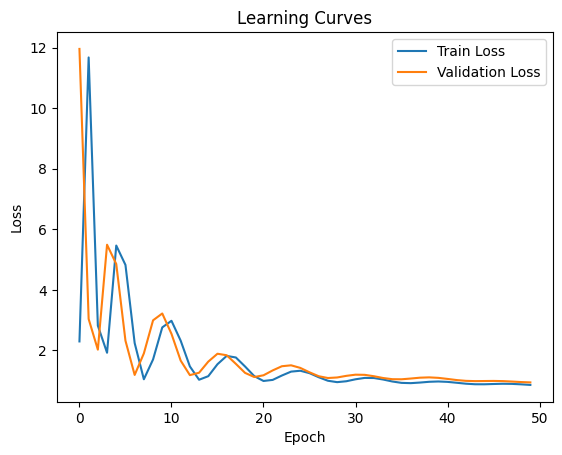

In [ ]:
import matplotlib.pyplot as plt

plt.figure() #⚠️
plt.plot(best_train, label="Train Loss")
plt.plot(best_val, label="Validation Loss")

plt.title("Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

print(f"{A}Mostrando curvas de aprendizaje...{E}")
plt.show()

## ⚠️ Disclaimer

Algunas partes de este notebook fueron asistidas mediante herramientas de inteligencia artificial.

Estas secciones han sido revisadas, comprendidas y adaptadas para cumplir con los objetivos de la actividad.

Las partes asistidas están claramente identificadas con el siguiente icono: ⚠️

